# LABORATORIUM 6 - LAS LOSOWY.

## 6.1 Implementacja lasu losowego

In [20]:
import numpy as np
from sklearn.datasets import make_blobs, make_classification, make_moons
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc
from matplotlib import pyplot as plt
import numpy as np
from collections import Counter
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


#### Funkcje do generowania danych oraz do wyświetlania wyników:

In [ ]:
def generate_data(n_samples, n_features, random_state):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    # y = 2 * y - 1
    return X, y

def generate_moons(n_samples, random_state):
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    # y_moons = 2 * y_moons - 1
    return X_moons, y_moons

def generate_blobs(n_samples, n_features, random_state, split_data=[0, 1]):
    centers_multi = [
        (-5, -5), (-5, 5),  
        (5, -5), (5, 5) 
    ]
    X_uni, y_uni = make_blobs(n_samples=n_samples, centers=centers_multi, n_features=n_features, random_state=random_state)
    y_uni = np.where(np.isin(y_uni, split_data), 0, 1)
    # y_uni = 2 * y_uni - 1
    return X_uni, y_uni

In [3]:
def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()


### Własna implementacja funkcji lasu losowego:

##### Drzewo losowe:

In [15]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

class RandomTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None
        self.n_classes = None
        self.n_features = None
        self.max_features = None

    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        self.n_features = X.shape[1]
        self.max_features = int(math.sqrt(self.n_features))
        self.tree = self.build_tree(X, y)

    def gini(self, y):
        counts = np.bincount(y, minlength=self.n_classes)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def information_gain(self, X, y, feature, threshold):
        parent_gini = self.gini(y)
        feature_data = X[:, feature]
        left_mask = feature_data <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0: 
            return 0

        left_gini = self.gini(y[left_mask])
        right_gini = self.gini(y[right_mask])
        n = len(y)
        n_left, n_right = np.sum(left_mask), np.sum(right_mask)
        child_gini = (n_left / n) * left_gini + (n_right / n) * right_gini
        return parent_gini - child_gini


    def find_best_threshold(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        # if self.max_features == 'sqrt':
        #     n_rand_features = int(np.sqrt(self.n_features))
        feature_indices = np.random.choice(self.n_features, self.max_features, replace=False)

        for feature in feature_indices:
            feature_values = X[:, feature]
            percentiles = np.percentile(feature_values, np.arange(10, 100, 10))
            thresholds = np.unique(percentiles)
            for threshold in thresholds:
                gain = self.information_gain(X, y, feature, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        n_samples = len(y)
        n_labels = len(np.unique(y))
        if n_labels == 1 or n_samples == 0:
            return Node(value=y[0])
        if self.max_depth is not None and depth >= self.max_depth:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        feature, threshold = self.find_best_threshold(X, y)
        if feature is None:
            leaf_value = Counter(y).most_common(1)[0][0]
            return Node(value=leaf_value)

        feature_data = X[:, feature]
        left_mask = feature_data <= threshold
        right_mask = ~left_mask
        left = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return Node(feature, threshold, left, right)
    
    def prepare_predict(self, x):
        node = self.tree
        while node.value is None:
            if x[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

    def predict(self, X):
        predictions = [self.prepare_predict(x) for x in X]
        return np.array(predictions)

##### Las losowy:

In [16]:
class RandomForest:
    def __init__(self, n_trees=100, max_depth=None, max_features='sqrt'):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = None
        self.trees = []
        self.bootstrap_indices = []
        self.oob_indices = []
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.max_features = int(np.sqrt(X.shape[1]))

        for _ in range(self.n_trees):
            choose_indices = np.random.choice(n_samples, n_samples, replace=True)
            oob = np.setdiff1d(np.arange(n_samples), choose_indices)
            self.bootstrap_indices.append(choose_indices)
            self.oob_indices.append(oob)

            tree = RandomTree(max_depth=self.max_depth)
            tree.fit(X[choose_indices], y[choose_indices])
            self.trees.append(tree)

    def predict(self, X):
        tree_predictions = np.array([tree.predict(X) for tree in self.trees])
        y_pred = []
        for preds in tree_predictions.T:
            y_pred.append(np.bincount(preds).argmax())
        return np.array(y_pred)
    
    def oob_score(self, X, y):
        n_samples = X.shape[0]
        votes = [list() for _ in range(n_samples)]
        for tree, oob_idx in zip(self.trees, self.oob_indices):
            if len(oob_idx) == 0:
                continue
            predictions = tree.predict(X[oob_idx])
            for idx, pred in zip(oob_idx, predictions):
                votes[idx].append(pred)
        oob_preds = np.array([np.bincount(v).argmax() if len(v) > 0 else -1 for v in votes])
        mask = oob_preds != -1
        return np.mean(oob_preds[mask] == y[mask])

#### Klasyfikacja modeli na *Generate data*:

23
Własny model na Generate Data:
Skuteczność: 99.7500%
Czułość (Recall): 99.4872%
Swoistość: 100.0000%
ROC AUC: 0.9974


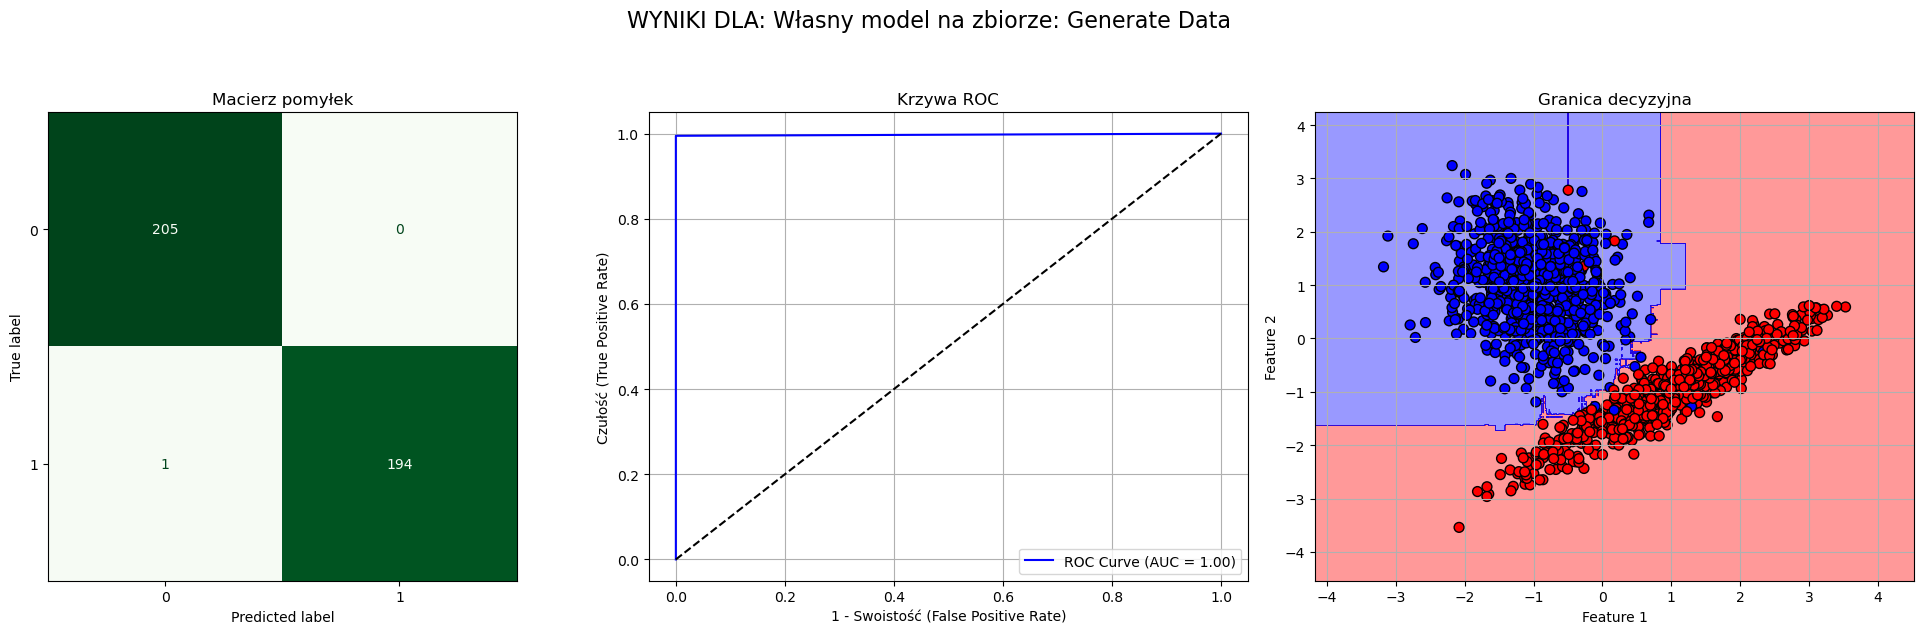

Sklearn na Generate Data:
Skuteczność: 99.5000%
Czułość (Recall): 99.4872%
Swoistość: 99.5122%
ROC AUC: 0.9950


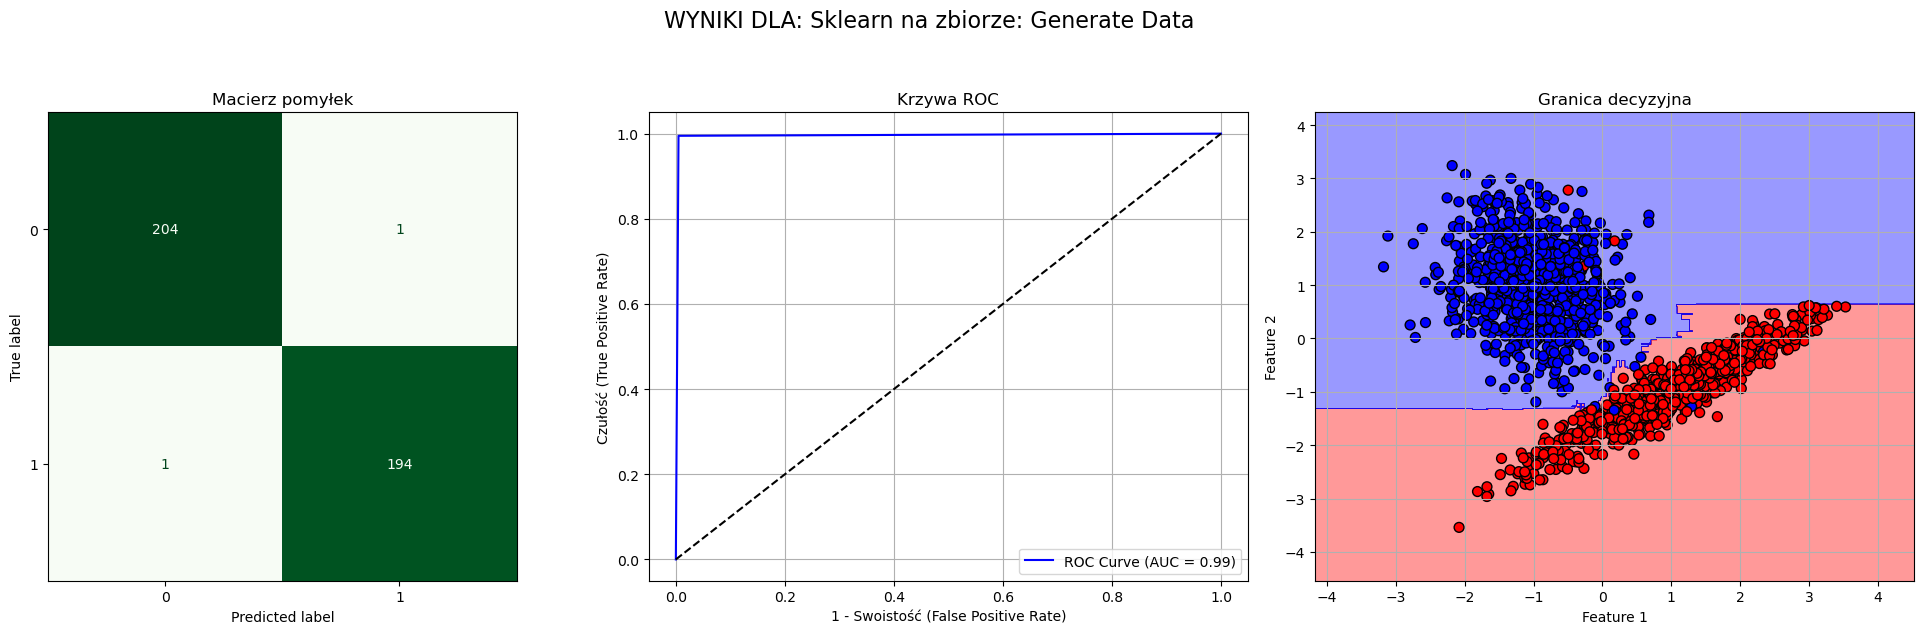

In [ ]:
X_generate, y_generate = generate_data(2000, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_generate, y_generate, test_size=0.2, random_state=259195)


def select_n_estimators(X, y, max_estimators=30):
    best_score = 0
    best_n = 1
    for n in range(1, max_estimators+1):
        rf = RandomForest(n_trees=n, max_depth=10)
        rf.fit(X, y)
        score = rf.oob_score(X, y)
        if score > best_score:
            best_score = score
            best_n = n
    return best_n

n_estimators_1 = select_n_estimators(X_gen_train, y_gen_train)
print(f"Znajdowana liczba drzew: {n_estimators_1}")

rf1 = RandomForest(n_trees=n_estimators_1, max_depth=10)
rf1.fit(X_gen_train, y_gen_train)
y_gen_pred = rf1.predict(X_gen_test)
evaluate_classifier(y_gen_test, y_gen_pred, X_gen_train, y_gen_train, rf1, "Własny model", "Generate Data")

sk_rf2 = RandomForestClassifier(n_estimators=n_estimators_1, max_depth=10, max_features='sqrt', oob_score=True, bootstrap=True, random_state=42)
sk_rf2.fit(X_gen_train, y_gen_train)
sk_y2_pred = sk_rf2.predict(X_gen_test)
evaluate_classifier(y_gen_test, sk_y2_pred, X_gen_train, y_gen_train, sk_rf2, "Sklearn", "Generate Data")

#### Klasyfikacja modeli na *Make moons*:

26
Własny model na Make Moons:
Skuteczność: 100.0000%
Czułość (Recall): 100.0000%
Swoistość: 100.0000%
ROC AUC: 1.0000


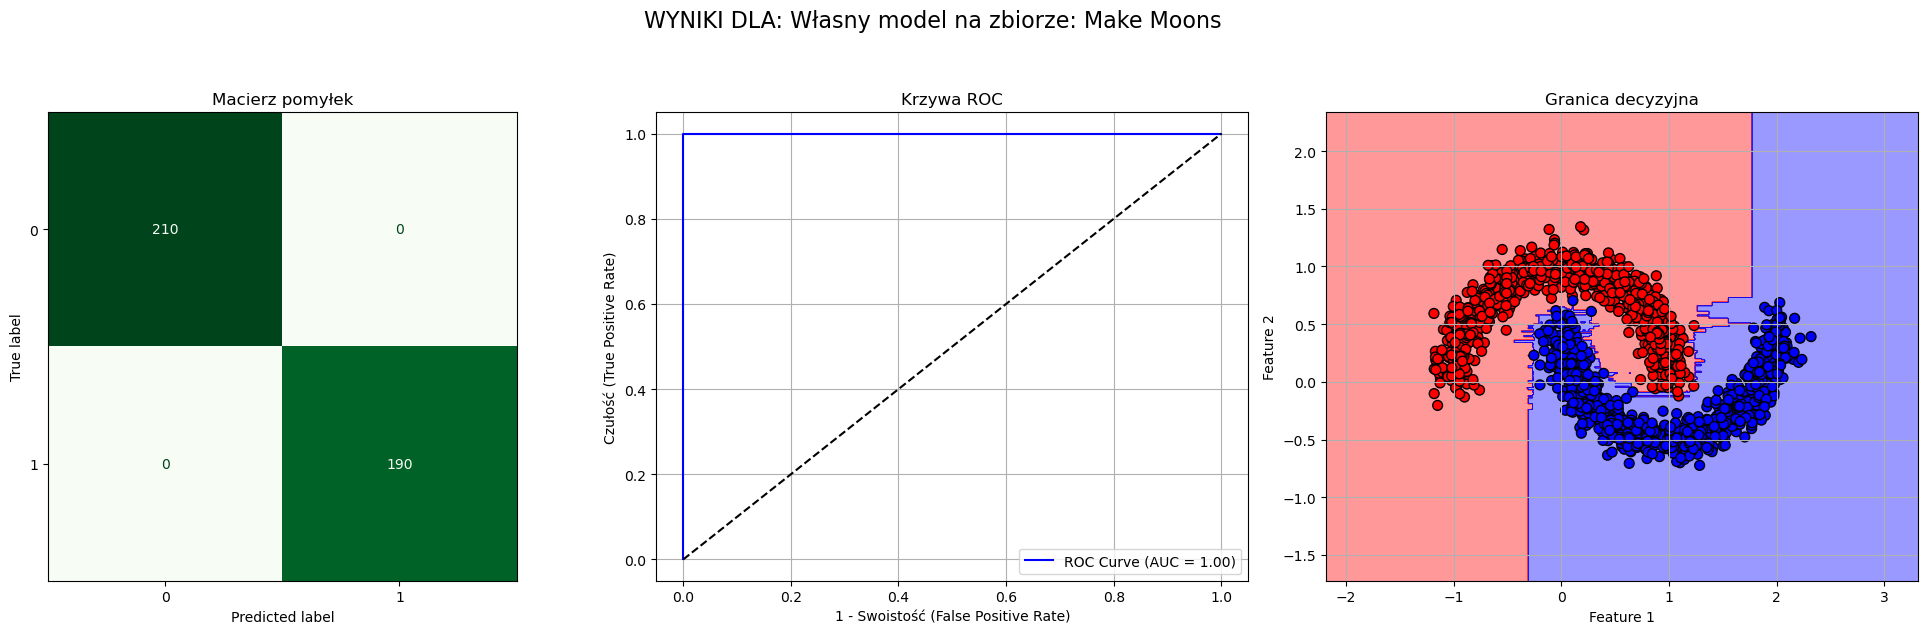

Sklearn na Make Moons:
Skuteczność: 100.0000%
Czułość (Recall): 100.0000%
Swoistość: 100.0000%
ROC AUC: 1.0000


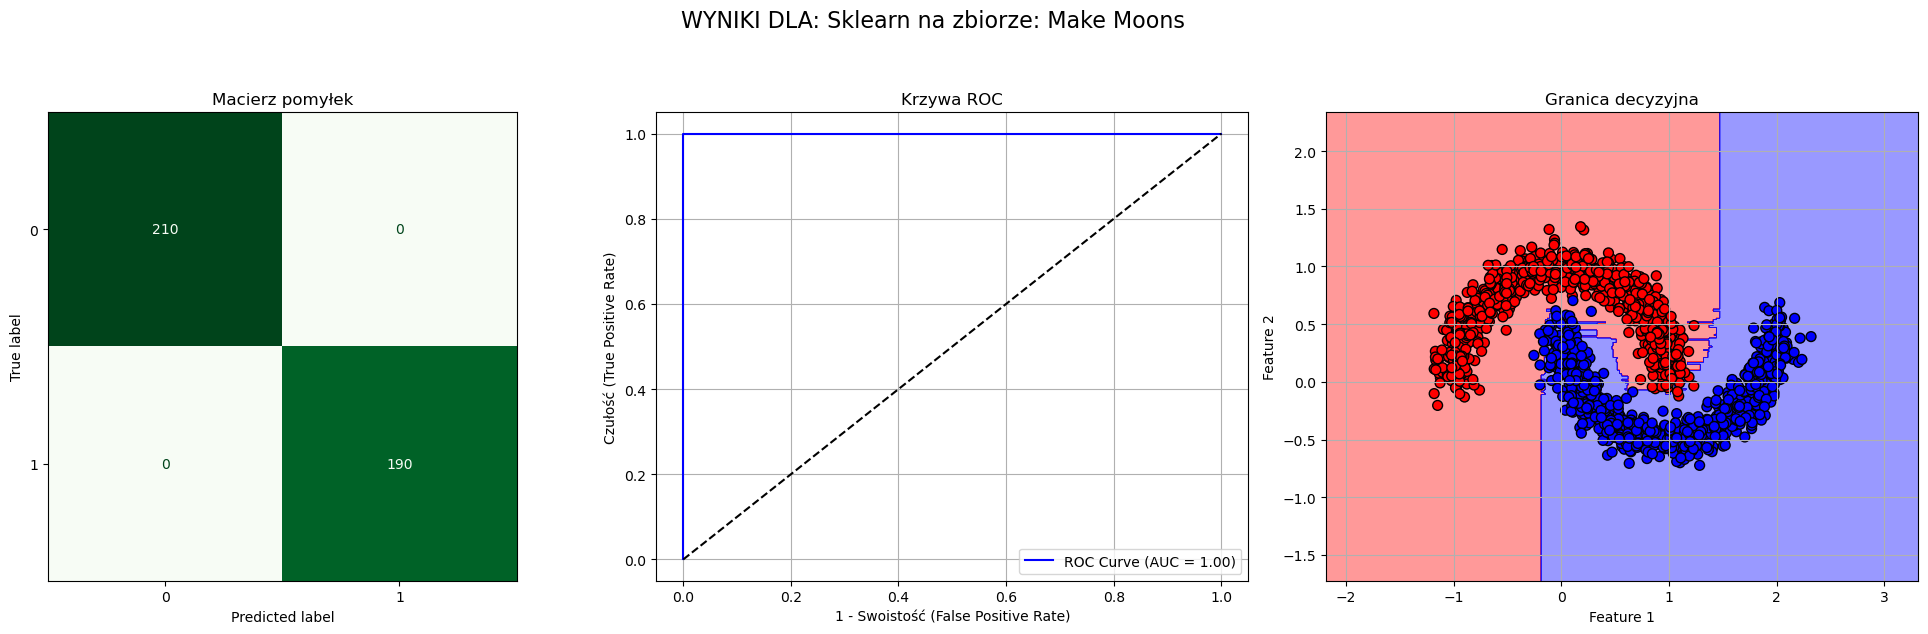

In [ ]:
X_moons, y_moons = generate_moons(2000, 259195)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=259195)

n_estimators_2 = select_n_estimators(X_m_train, y_m_train)
print(f"Znaleziona liczba drzew: {n_estimators_2}")

rf2 = RandomForest(n_trees=n_estimators_2, max_depth=10)
rf2.fit(X_m_train, y_m_train)
y2_pred = rf2.predict(X_m_test)
evaluate_classifier(y_m_test, y2_pred, X_m_train, y_m_train, rf2, "Własny model", "Make Moons")

sk_rf2 = RandomForestClassifier(n_estimators=n_estimators_2, max_depth=10, max_features='sqrt', oob_score=True, bootstrap=True, random_state=42)
sk_rf2.fit(X_m_test, y_m_test)
sk_y2_pred = sk_rf2.predict(X_m_test)
evaluate_classifier(y_m_test, sk_y2_pred, X_m_train, y_m_train, sk_rf2, "Sklearn", "Make Moons")

#### Klasyfikacja modeli na wielomodowym *Make blobs*:

Znaleziona liczba drzew: 18
Własny model na Make Blobs:
Skuteczność: 99.5000%
Czułość (Recall): 98.9691%
Swoistość: 100.0000%
ROC AUC: 0.9948


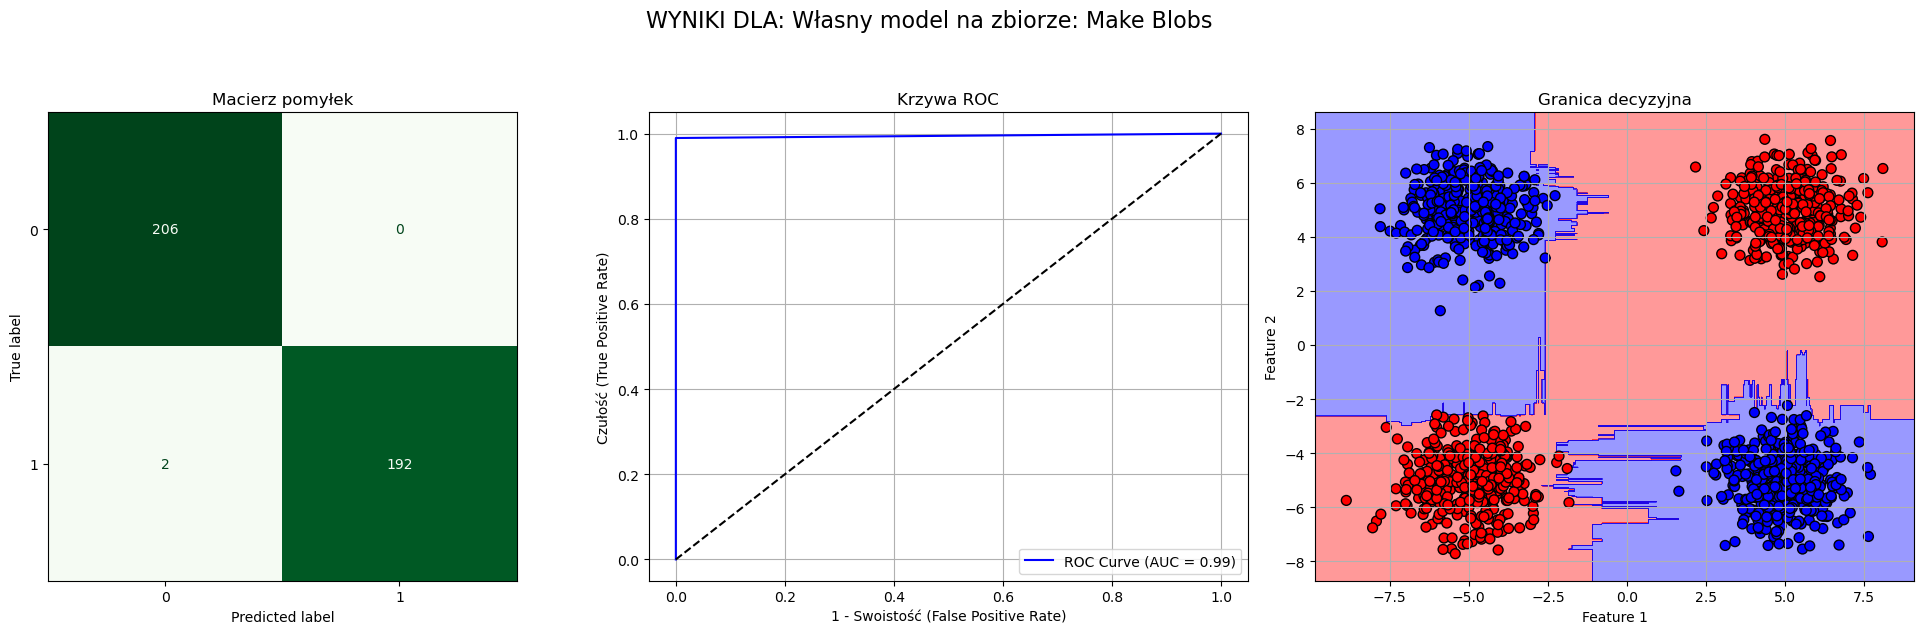

c:\Users\jasin\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


Sklearn na Make Blobs:
Skuteczność: 100.0000%
Czułość (Recall): 100.0000%
Swoistość: 100.0000%
ROC AUC: 1.0000


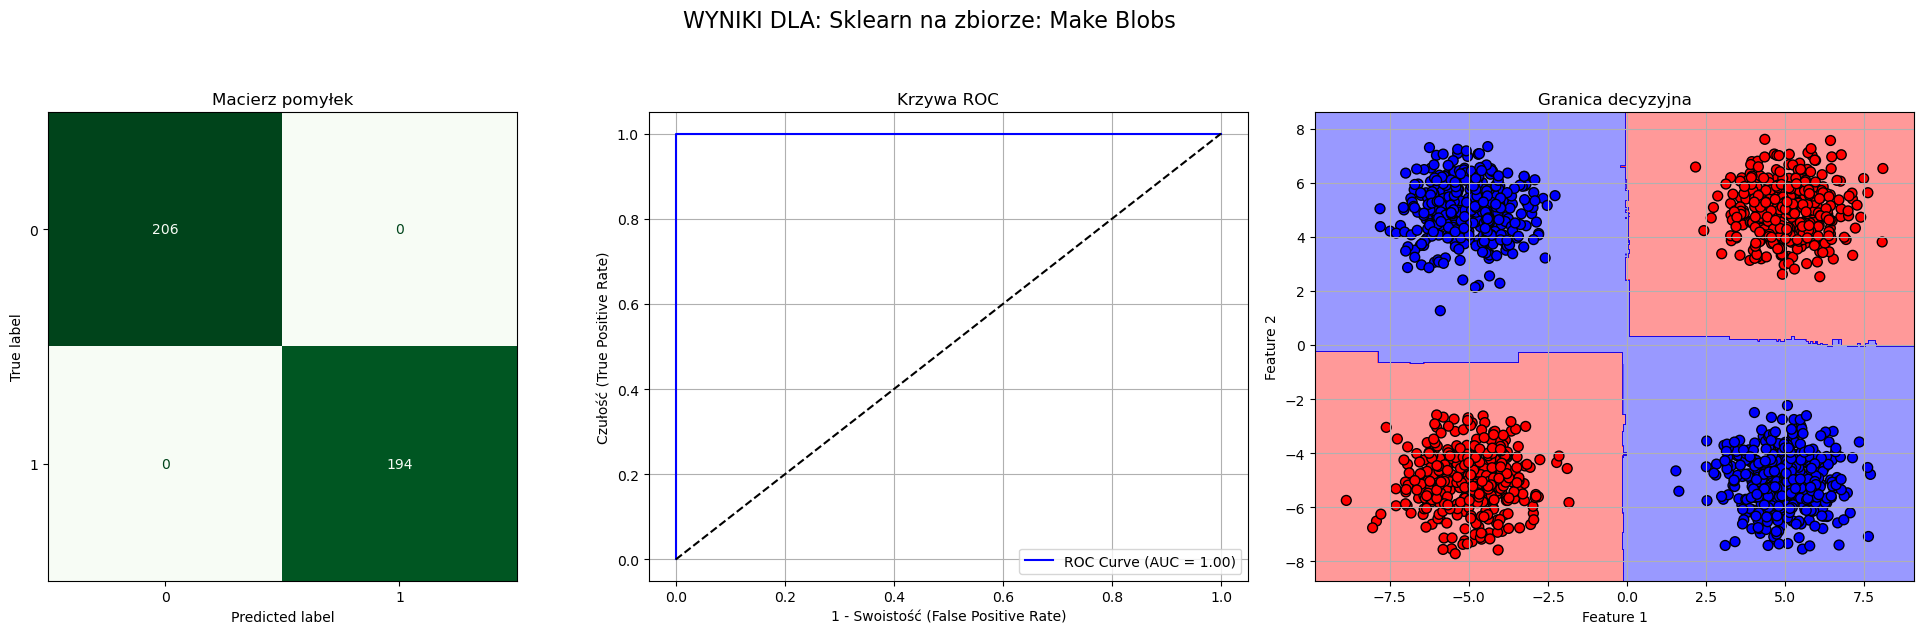

In [23]:
X_blobs, y_blobs = generate_blobs(2000, 2, 259195, split_data=[0, 3])
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_blobs, y_blobs, test_size=0.2, random_state=259195)

n_estimators_3 = select_n_estimators(X_b_train, y_b_train)
print(f"Znaleziona liczba drzew: {n_estimators_3}")

rf3 = RandomForest(n_trees=n_estimators_3, max_depth=10)
rf3.fit(X_b_train, y_b_train)
y3_pred = rf3.predict(X_b_test)
evaluate_classifier(y_b_test, y3_pred, X_b_train, y_b_train, rf3, "Własny model", "Make Blobs")

sk_rf3 = RandomForestClassifier(n_estimators=n_estimators_3, max_depth=10, max_features='sqrt', oob_score=True, bootstrap=True, random_state=42)
sk_rf3.fit(X_b_train, y_b_train)
sk_y3_pred = sk_rf3.predict(X_b_test)
evaluate_classifier(y_b_test, sk_y3_pred, X_b_train, y_b_train, sk_rf3, "Sklearn", "Make Blobs")